# LSTM Train Model

## Base Initialization

### Global Parameters

In [1]:
stock_code = "GAS"

In [2]:
output_column = "close"

In [3]:
stock_code = str.lower(stock_code)

### Install libraries

In [4]:
# !pip install -r requirements.txt

### Import libraries

In [5]:
import os
# Set CUBLAS_WORKSPACE_CONFIG for reproducibility
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import sys
import random
import numpy as np
import torch
import pickle
from pathlib import Path


# go one level up from where the notebook is running
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from data_preprocessor.data_preprocessor import DataPreprocessor
from dtos.model_dtos.model_config_dto import ModelConfigDto
from logger.logger import Logger, LogType
from model.lstm_model import LSTM_Model
from train_test_creator.train_test_creator import TrainTestCreator
from web_scraper.web_scraper import WebScraper
from utils.constants import *
from utils.enums import *
from utils.utils import plot_model_result_vertical, set_seed

os.environ["WANDB_DISABLE_SYMLINKS"] = "true"

In [6]:
SEED = RANDOM_SEED

# Apply globally
set_seed(SEED)
# random.seed(SEED)
# np.random.seed(SEED)

In [7]:
input_size = DEFAULT_INPUT_SIZE
forecast_size = DEFAULT_FORECAST_SIZE

print(f"Input size: {input_size}")
print(f"Forecast size: {forecast_size}")

Input size: 240
Forecast size: 30


### Log Metadata

In [8]:
my_logger = Logger(
    file_name=f"{TRAINED_MODELS_LOG_FILE_BASE}/{stock_code}_lstm_train_log"
)

In [9]:
my_logger.log_info(
    f"\nTRAIN MODEL FOR STOCK: '{stock_code}' - {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}"
)

### Load Dataframe

In [10]:
my_train_test_creator = TrainTestCreator(logger=my_logger)

In [11]:
dataframe = my_train_test_creator.load_dataframe(
    stock_code=stock_code, file_path=f"../../unified_dataframe/unified_{stock_code}.csv"
)
dataframe

,date,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,...,eom_20,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10
0,2013-03-06,4.707945,42.573445,318.035806,275.767367,9.470968,428.666774,40.638065,31.087742,1423.448966,...,-0.037691,0.044115,1220.608792,964.909607,0.144175,0.147936,-0.003761,69.547974,522.980011,-7875.073746
1,2013-03-07,4.710027,42.585916,324.596774,275.848142,9.706129,428.922903,41.177742,31.329032,1423.865911,...,0.006026,0.045669,1212.631110,964.909607,0.140278,0.146404,-0.006126,45.861928,454.820285,-25492.795995
2,2013-03-08,4.712110,42.598386,331.157742,275.928918,9.941290,429.179032,41.717419,31.570323,1424.282855,...,-0.031238,0.021012,1212.631110,964.909607,0.135737,0.144271,-0.008534,-34.331403,384.941472,-14313.561330
3,2013-03-11,4.718356,42.635797,350.840645,276.171244,10.646774,429.947419,43.336452,32.294194,1425.533689,...,-0.087321,0.025443,1212.631110,964.909607,0.130898,0.141596,-0.010698,-64.185869,320.780424,-8878.216392
4,2013-03-12,4.720438,42.648267,357.401613,276.252019,10.881935,430.203548,43.876129,32.535484,1425.950634,...,-0.063236,0.059730,1217.949564,964.909607,0.126369,0.138551,-0.012182,-53.492223,267.312903,1734.980337
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3022,2025-06-20,7.846813,106.966667,936.533333,579.360000,72.863333,315.580000,222.863333,224.926667,2770.786667,...,0.405180,0.028466,4676.758295,839.897191,0.030031,0.022065,0.007966,6608.683126,4585.012125,-162996.860877
3023,2025-06-23,7.880769,106.676667,927.445333,586.434000,71.482333,302.707000,222.304333,227.240667,2738.915667,...,0.454877,0.061912,4885.361903,839.897191,0.034203,0.024492,0.009711,7724.802154,5033.553558,-8951.424861
3024,2025-06-25,7.903407,106.483333,921.386667,591.150000,70.561667,294.125000,221.931667,228.783333,2717.668333,...,0.247208,0.001295,4885.361903,780.896149,0.037826,0.027159,0.010667,6231.077840,5204.628455,-328713.260795
3025,2025-06-26,7.914725,106.386667,918.357333,593.508000,70.101333,289.834000,221.745333,229.554667,2707.044667,...,0.120171,-0.002004,4885.361903,792.464981,0.040591,0.029846,0.010746,5858.265949,5298.005240,-155238.649006


In [12]:
dataframe.shape

(3027, 356)

## Find output range

In [13]:
dataframe.close.min(), dataframe.close.max()

(15.7183, 95.4676)

## Create train test set

In [14]:
train_test_set = my_train_test_creator.create_train_test_set(
    dataframe=dataframe,
    output_column=output_column,
    stock_code=stock_code,
    input_size=input_size,
    forecast_size=forecast_size,
)

Feature Selector Types:
['XGB_REGRESSOR', 'LASSO', 'ELASTIC_NET', 'XGB_SHAP']

Fitting feature selectors...

Fitting XGB feature selector...
Done fitting XGB feature selector...
Fitting LASSO feature selector...


d:\GIT\master-thesis\mt_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.486e+02, tolerance: 9.160e+01
  model = cd_fast.enet_coordinate_descent(


Done fitting LASSO feature selector...
Fitting ELASTC NET feature selector...


d:\GIT\master-thesis\mt_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.200e+02, tolerance: 9.160e+01
  model = cd_fast.enet_coordinate_descent(


Done fitting ELASTC NET feature selector...
Fitting XGB SHAP feature selector...
Done fitting XGB SHAP feature selector...

Done fitting feature selectors...
🔍 Dropped 26 highly correlated features (|r| >= 0.85):
['close_bb_lower_20', 'close_bb_middle_20', 'close_bb_upper_20', 'close_ema_12', 'close_ema_26', 'close_lwma_12', 'close_lwma_26', 'close_lwma_50', 'close_sma_50', 'close_wma_100', 'close_wma_14', 'close_wma_21', 'close_wma_50', 'close_wma_7', 'kc_lower_20', 'kc_middle_20', 'kc_upper_20', 'low', 'macd_signal_9', 'open', 'roc_9', 'starc_lower_20', 'starc_middle_20', 'starc_upper_20', 'tsi_13_7_signal_7', 'vn_index_close']
✅ Kept 14 features after pruning correlation redundancy.


### Train set

In [15]:
train_test_set.get_train_set()

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10,close
0,4.707945,42.573445,318.035806,275.767367,9.470968,428.666774,40.638065,31.087742,1423.448966,111.510968,...,0.044115,1220.608792,964.909607,0.144175,0.147936,-0.003761,69.547974,522.980011,-7875.073746,20.8390
1,4.710027,42.585916,324.596774,275.848142,9.706129,428.922903,41.177742,31.329032,1423.865911,113.366129,...,0.045669,1212.631110,964.909607,0.140278,0.146404,-0.006126,45.861928,454.820285,-25492.795995,20.7028
2,4.712110,42.598386,331.157742,275.928918,9.941290,429.179032,41.717419,31.570323,1424.282855,115.221290,...,0.021012,1212.631110,964.909607,0.135737,0.144271,-0.008534,-34.331403,384.941472,-14313.561330,20.7028
3,4.718356,42.635797,350.840645,276.171244,10.646774,429.947419,43.336452,32.294194,1425.533689,120.786774,...,0.025443,1212.631110,964.909607,0.130898,0.141596,-0.010698,-64.185869,320.780424,-8878.216392,20.7028
4,4.720438,42.648267,357.401613,276.252019,10.881935,430.203548,43.876129,32.535484,1425.950634,122.641935,...,0.059730,1217.949564,964.909607,0.126369,0.138551,-0.012182,-53.492223,267.312903,1734.980337,20.7936
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2602,5.265326,90.646273,838.333333,850.000000,58.666667,250.000000,195.000000,189.166667,2641.666667,69.166667,...,0.725939,3802.199842,1210.642004,0.058718,0.055510,0.003209,246.032589,752.059956,-60879.933342,81.4450
2603,5.278261,90.658743,840.666667,860.000000,58.933333,252.000000,194.000000,187.333333,2633.333333,68.333333,...,0.645253,3802.199842,1201.173295,0.059309,0.056270,0.003040,8.395000,645.822105,-39071.162751,80.8080
2604,5.291196,90.671213,843.000000,870.000000,59.200000,254.000000,193.000000,185.500000,2625.000000,67.500000,...,0.424303,3806.481598,1201.173295,0.059857,0.056987,0.002870,-547.262839,475.381399,-78540.116661,80.8990
2605,5.304130,90.683683,845.333333,880.000000,59.466667,256.000000,192.000000,183.666667,2616.666667,66.666667,...,0.557959,3917.807269,1201.173295,0.060941,0.057778,0.003163,6.997533,408.469418,26423.966291,83.2650


In [16]:
train_test_set.get_train_set().shape

(2607, 329)

### Val set

In [17]:
train_test_set.get_val_set()

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10,close
0,5.360217,90.733564,850.000000,905.161290,60.000000,261.290323,188.709677,180.000000,2600.000000,64.677419,...,0.473692,3917.807269,1172.292626,0.062401,0.059368,0.003033,-512.518446,181.551574,-73832.577230,81.263
1,5.375326,90.746035,850.000000,907.741935,60.000000,261.935484,188.064516,180.000000,2600.000000,64.516129,...,0.318800,3786.190004,1172.292626,0.062719,0.060038,0.002681,-905.186314,26.303304,-115150.792910,78.533
2,5.390435,90.758505,850.000000,910.322581,60.000000,262.580645,187.419355,180.000000,2600.000000,64.354839,...,0.284335,3764.253793,1172.292626,0.062975,0.060626,0.002349,-990.613598,-118.970539,-47981.892829,78.078
3,5.405543,90.770975,850.000000,912.903226,60.000000,263.225806,186.774194,180.000000,2600.000000,64.193548,...,0.220755,3764.253793,1150.431691,0.063121,0.061125,0.001996,-1199.108124,-273.275908,-87299.953775,76.622
4,5.420652,90.783445,850.000000,915.483871,60.000000,263.870968,186.129032,180.000000,2600.000000,64.032258,...,0.144198,3764.253793,1150.431691,0.062910,0.061482,0.001428,-1256.056463,-413.673130,-69514.703119,76.622
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,6.417143,92.180114,738.064516,900.000000,68.387097,550.000000,256.774194,249.677419,2951.612903,206.774194,...,-0.072259,3673.082541,1052.967083,0.048489,0.049554,-0.001065,-93.710571,230.214108,-21769.068134,68.432
86,6.382198,92.217525,733.225806,900.000000,69.354839,580.000000,258.709677,243.870968,2980.645161,208.709677,...,-0.084217,3741.464396,1052.967083,0.048278,0.049299,-0.001020,315.481359,242.395144,117224.221207,69.706
87,6.370549,92.229995,731.612903,900.000000,69.677419,590.000000,259.354839,241.935484,2990.322581,209.354839,...,-0.083112,3741.464396,1050.217821,0.047935,0.049026,-0.001091,392.663472,263.862048,45843.335422,69.524
88,6.358901,92.242465,730.000000,900.000000,70.000000,600.000000,260.000000,240.000000,3000.000000,210.000000,...,-0.050656,3692.492349,1050.217821,0.047532,0.048727,-0.001195,206.387611,255.651414,-71084.723548,68.614


In [18]:
train_test_set.get_val_set().shape

(90, 329)

### Test set

In [19]:
train_test_set.get_test_set()

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10,close
0,6.335604,92.267406,717.586207,879.310345,67.931034,572.413793,255.862069,237.241379,2917.241379,206.551724,...,-0.015217,3677.820194,1051.610683,0.046569,0.048024,-0.001456,47.656550,214.599201,-63746.220441,68.432
1,5.827473,93.140323,684.094000,720.000000,59.000000,310.000000,336.000000,250.000000,2760.000000,308.000000,...,0.183737,3677.820194,1114.539514,0.045988,0.047617,-0.001629,174.019712,208.802131,4934.094042,72.527
2,6.300659,92.304816,698.965517,848.275862,64.827586,531.034483,249.655172,233.103448,2793.103448,201.379310,...,0.078857,3470.164098,1114.539514,0.045445,0.047183,-0.001738,64.274112,188.155271,-82355.166667,68.432
3,6.289011,92.317287,692.758621,837.931034,63.793103,517.241379,247.586207,231.724138,2751.724138,199.655172,...,0.074534,3493.236998,1114.539514,0.045062,0.046759,-0.001696,204.226740,190.451195,40032.764026,68.887
4,6.277363,92.329757,686.551724,827.586207,62.758621,503.448276,245.517241,230.344828,2710.344828,197.931034,...,0.103196,3493.236998,1114.539514,0.044582,0.046323,-0.001741,177.882924,188.655728,-10147.774416,68.887
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
325,7.846813,106.966667,936.533333,579.360000,72.863333,315.580000,222.863333,224.926667,2770.786667,128.453333,...,0.028466,4676.758295,839.897191,0.030031,0.022065,0.007966,6608.683126,4585.012125,-162996.860877,69.500
326,7.880769,106.676667,927.445333,586.434000,71.482333,302.707000,222.304333,227.240667,2738.915667,125.590333,...,0.061912,4885.361903,839.897191,0.034203,0.024492,0.009711,7724.802154,5033.553558,-8951.424861,72.600
327,7.903407,106.483333,921.386667,591.150000,70.561667,294.125000,221.931667,228.783333,2717.668333,123.681667,...,0.001295,4885.361903,780.896149,0.037826,0.027159,0.010667,6231.077840,5204.628455,-328713.260795,67.500
328,7.914725,106.386667,918.357333,593.508000,70.101333,289.834000,221.745333,229.554667,2707.044667,122.727333,...,-0.002004,4885.361903,792.464981,0.040591,0.029846,0.010746,5858.265949,5298.005240,-155238.649006,68.500


In [20]:
train_test_set.get_test_set().shape

(330, 329)

### Normalized train set

In [21]:
train_test_set.get_norm_train_set()

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10,close
0,0.548284,0.000000,0.000000,0.169956,0.000000,0.542525,0.000000,0.000000,0.005678,0.261530,...,0.233857,0.000875,0.467761,0.578960,0.593050,0.304170,0.443745,0.486007,0.447933,0.064210
1,0.548388,0.000190,0.008390,0.170065,0.003334,0.542947,0.002578,0.000781,0.005779,0.269747,...,0.233961,0.000000,0.467761,0.571400,0.590011,0.279650,0.442942,0.482295,0.432703,0.062502
2,0.548493,0.000379,0.016781,0.170174,0.006668,0.543370,0.005155,0.001562,0.005880,0.277963,...,0.232312,0.000000,0.467761,0.562588,0.585776,0.254679,0.440227,0.478488,0.442367,0.062502
3,0.548808,0.000948,0.041952,0.170502,0.016671,0.544638,0.012889,0.003905,0.006182,0.302612,...,0.232609,0.000000,0.467761,0.553199,0.580468,0.232236,0.439216,0.474994,0.447066,0.062502
4,0.548913,0.001138,0.050342,0.170611,0.020005,0.545061,0.015466,0.004687,0.006283,0.310828,...,0.234901,0.000583,0.467761,0.544412,0.574424,0.216856,0.439578,0.472081,0.456240,0.063641
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2602,0.576377,0.731184,0.665373,0.945946,0.697524,0.247602,0.737297,0.511728,0.300646,0.073992,...,0.279448,0.284006,0.657436,0.413148,0.409614,0.376442,0.449721,0.498484,0.402113,0.824166
2603,0.577029,0.731374,0.668357,0.959459,0.701305,0.250904,0.732521,0.505793,0.298628,0.070301,...,0.274053,0.284006,0.650127,0.414294,0.411122,0.374687,0.441674,0.492698,0.420965,0.816179
2604,0.577681,0.731563,0.671340,0.972973,0.705086,0.254205,0.727744,0.499858,0.296610,0.066611,...,0.259279,0.284476,0.650127,0.415358,0.412546,0.372932,0.422857,0.483414,0.386846,0.817320
2605,0.578333,0.731753,0.674324,0.986486,0.708867,0.257506,0.722968,0.493923,0.294592,0.062920,...,0.268216,0.296685,0.650127,0.417461,0.414115,0.375970,0.441626,0.479770,0.477582,0.846988


### Normalized val set

In [22]:
train_test_set.get_norm_val_set()

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10,close
0,0.581160,0.732512,0.680292,1.020488,0.716429,0.266239,0.707252,0.482054,0.290557,0.054110,...,0.262581,0.296685,0.627835,0.420294,0.417271,0.374624,0.424034,0.467410,0.390916,0.821884
1,0.581922,0.732701,0.680292,1.023976,0.716429,0.267304,0.704170,0.482054,0.290557,0.053395,...,0.252224,0.282250,0.627835,0.420910,0.418601,0.370968,0.410736,0.458954,0.355198,0.787652
2,0.582683,0.732891,0.680292,1.027463,0.716429,0.268369,0.701089,0.482054,0.290557,0.052681,...,0.249920,0.279845,0.627835,0.421406,0.419767,0.367529,0.407844,0.451042,0.413262,0.781947
3,0.583445,0.733081,0.680292,1.030950,0.716429,0.269434,0.698007,0.482054,0.290557,0.051967,...,0.245668,0.279845,0.610961,0.421690,0.420757,0.363870,0.400783,0.442637,0.379274,0.763689
4,0.584206,0.733270,0.680292,1.034438,0.716429,0.270499,0.694926,0.482054,0.290557,0.051252,...,0.240549,0.279845,0.610961,0.421281,0.421466,0.357982,0.398855,0.434990,0.394648,0.763689
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,0.634433,0.754514,0.537146,1.013514,0.835346,0.742807,1.032356,0.707611,0.375693,0.683441,...,0.226076,0.269846,0.535731,0.393299,0.397793,0.332123,0.438216,0.470061,0.435922,0.660993
86,0.632671,0.755083,0.530958,1.013514,0.849067,0.792328,1.041601,0.688814,0.382723,0.692013,...,0.225276,0.277345,0.535731,0.392891,0.397287,0.332589,0.452073,0.470724,0.556075,0.676968
87,0.632084,0.755272,0.528895,1.013514,0.853641,0.808834,1.044683,0.682549,0.385066,0.694871,...,0.225350,0.277345,0.533608,0.392224,0.396745,0.331853,0.454687,0.471894,0.494370,0.674686
88,0.631497,0.755462,0.526833,1.013514,0.858214,0.825341,1.047764,0.676283,0.387409,0.697728,...,0.227520,0.271974,0.533608,0.391442,0.396152,0.330775,0.448378,0.471446,0.393291,0.663275


### Normalized test set

In [23]:
train_test_set.get_norm_test_set()

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10,close
0,0.630323,0.755841,0.510957,0.985555,0.828879,0.779805,1.028000,0.667353,0.367371,0.682456,...,0.229890,0.270365,0.534684,0.389573,0.394758,0.328073,0.443003,0.469210,0.399635,0.660993
1,0.604711,0.769118,0.468127,0.770270,0.702250,0.346643,1.410772,0.708655,0.329298,1.131760,...,0.243193,0.270365,0.583257,0.388446,0.393949,0.326275,0.447282,0.468895,0.459006,0.712341
2,0.628561,0.756410,0.487145,0.943616,0.784877,0.711501,0.998353,0.653958,0.337313,0.659548,...,0.236180,0.247591,0.583257,0.387393,0.393087,0.325151,0.443566,0.467770,0.383549,0.660993
3,0.627974,0.756600,0.479207,0.929637,0.770210,0.688733,0.988471,0.649493,0.327294,0.651912,...,0.235891,0.250121,0.583257,0.386650,0.392245,0.325581,0.448305,0.467895,0.489347,0.666698
4,0.627387,0.756790,0.471270,0.915657,0.755542,0.665965,0.978588,0.645028,0.317275,0.644276,...,0.237808,0.250121,0.583257,0.385719,0.391381,0.325117,0.447413,0.467797,0.445968,0.666698
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
325,0.706493,0.979416,0.790954,0.580216,0.898812,0.355854,0.870384,0.627489,0.331910,0.336566,...,0.232811,0.379922,0.371267,0.357485,0.343236,0.425776,0.665184,0.707256,0.313838,0.674385
326,0.708204,0.975005,0.779332,0.589776,0.879232,0.334605,0.867714,0.634979,0.324193,0.323887,...,0.235047,0.402800,0.371267,0.365580,0.348054,0.443864,0.702980,0.731687,0.447002,0.713256
327,0.709345,0.972064,0.771584,0.596149,0.866178,0.320439,0.865934,0.639973,0.319048,0.315433,...,0.230994,0.402800,0.325725,0.372610,0.353347,0.453780,0.652397,0.741005,0.170585,0.649306
328,0.709916,0.970594,0.767710,0.599335,0.859651,0.313356,0.865044,0.642470,0.316476,0.311207,...,0.230773,0.402800,0.334655,0.377975,0.358678,0.454596,0.639772,0.746091,0.320545,0.661845


### Train windows

In [24]:
print(f"Number of train windows: {len(train_test_set.get_train_windows())}")

Number of train windows: 2337


In [25]:
train_test_set.get_train_windows()[0]

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10,close
0,0.548284,0.000000,0.000000,0.169956,0.000000,0.542525,0.000000,0.000000,0.005678,0.261530,...,0.233857,0.000875,0.467761,0.578960,0.593050,0.304170,0.443745,0.486007,0.447933,0.064210
1,0.548388,0.000190,0.008390,0.170065,0.003334,0.542947,0.002578,0.000781,0.005779,0.269747,...,0.233961,0.000000,0.467761,0.571400,0.590011,0.279650,0.442942,0.482295,0.432703,0.062502
2,0.548493,0.000379,0.016781,0.170174,0.006668,0.543370,0.005155,0.001562,0.005880,0.277963,...,0.232312,0.000000,0.467761,0.562588,0.585776,0.254679,0.440227,0.478488,0.442367,0.062502
3,0.548808,0.000948,0.041952,0.170502,0.016671,0.544638,0.012889,0.003905,0.006182,0.302612,...,0.232609,0.000000,0.467761,0.553199,0.580468,0.232236,0.439216,0.474994,0.447066,0.062502
4,0.548913,0.001138,0.050342,0.170611,0.020005,0.545061,0.015466,0.004687,0.006283,0.310828,...,0.234901,0.000583,0.467761,0.544412,0.574424,0.216856,0.439578,0.472081,0.456240,0.063641
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,0.568037,0.076817,0.415868,0.214164,0.176580,0.400291,0.133701,0.142524,0.046565,0.850525,...,0.247518,0.108423,0.601249,0.661802,0.637466,0.514824,0.438292,0.446309,0.392620,0.358600
266,0.568171,0.077007,0.418362,0.214273,0.177237,0.394937,0.134179,0.143010,0.046665,0.840560,...,0.243296,0.108423,0.577639,0.674645,0.646664,0.535400,0.424465,0.444022,0.367487,0.343662
267,0.568305,0.077196,0.420856,0.214382,0.177894,0.389583,0.134656,0.143497,0.046766,0.830595,...,0.239785,0.108423,0.591804,0.686477,0.656444,0.547542,0.432651,0.443942,0.390498,0.352624
268,0.568439,0.077386,0.423350,0.214492,0.178551,0.384229,0.135134,0.143983,0.046867,0.820630,...,0.241418,0.108423,0.582360,0.696034,0.666222,0.547525,0.424245,0.441943,0.376076,0.346649


### Val windows

In [26]:
print(f"Number of val windows: {len(train_test_set.get_val_windows())}")

Number of val windows: 60


In [27]:
train_test_set.get_val_windows()[0]

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10,close
0,0.915082,0.666696,0.744234,0.804272,0.478595,0.389774,0.791995,0.628248,0.188237,0.153403,...,0.176190,0.488086,0.348193,0.404348,0.412024,0.316826,0.464501,0.486398,0.431648,0.820604
1,0.910836,0.666885,0.744234,0.807323,0.480882,0.399359,0.793536,0.635558,0.184332,0.150545,...,0.175479,0.467364,0.348193,0.403367,0.410814,0.317899,0.444864,0.483071,0.407840,0.786650
2,0.898098,0.667454,0.744234,0.816478,0.487742,0.428113,0.798158,0.657487,0.172616,0.141973,...,0.157409,0.467364,0.348193,0.402746,0.409720,0.320297,0.435557,0.478081,0.447717,0.786650
3,0.893852,0.667644,0.744234,0.819529,0.490029,0.437697,0.799699,0.664797,0.168710,0.139116,...,0.156971,0.467364,0.348193,0.402052,0.408702,0.321905,0.426806,0.471793,0.445376,0.786650
4,0.889606,0.667834,0.744234,0.822581,0.492316,0.447282,0.801239,0.672106,0.164805,0.136258,...,0.162423,0.467364,0.352858,0.400828,0.407638,0.320926,0.428919,0.466889,0.454584,0.793991
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,0.607814,0.739150,0.667504,1.140541,0.730607,0.303726,0.675204,0.495002,0.288136,0.051109,...,0.208596,0.277147,0.561600,0.403209,0.414431,0.298160,0.395820,0.355123,0.431633,0.704354
266,0.608575,0.739340,0.665373,1.143694,0.732970,0.304826,0.684756,0.497160,0.287732,0.054062,...,0.213932,0.277147,0.559477,0.400563,0.412166,0.295850,0.405916,0.361600,0.475339,0.702071
267,0.609337,0.739530,0.663241,1.146847,0.735334,0.305927,0.694309,0.499318,0.287328,0.057015,...,0.212885,0.283393,0.559477,0.398243,0.409880,0.295395,0.419055,0.370171,0.498812,0.715764
268,0.610098,0.739719,0.661110,1.150000,0.737697,0.307027,0.703862,0.501477,0.286925,0.059967,...,0.212321,0.283393,0.559477,0.396427,0.407680,0.297185,0.429789,0.379984,0.453585,0.715764


### Test windows

In [28]:
print(f"Number of test windows: {len(train_test_set.get_test_windows())}")

Number of test windows: 60


In [29]:
train_test_set.get_test_windows()[0]

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10,close
0,0.630323,0.755841,0.510957,0.985555,0.828879,0.779805,1.028000,0.667353,0.367371,0.682456,...,0.229890,0.270365,0.534684,0.389573,0.394758,0.328073,0.443003,0.469210,0.399635,0.660993
1,0.604711,0.769118,0.468127,0.770270,0.702250,0.346643,1.410772,0.708655,0.329298,1.131760,...,0.243193,0.270365,0.583257,0.388446,0.393949,0.326275,0.447282,0.468895,0.459006,0.712341
2,0.628561,0.756410,0.487145,0.943616,0.784877,0.711501,0.998353,0.653958,0.337313,0.659548,...,0.236180,0.247591,0.583257,0.387393,0.393087,0.325151,0.443566,0.467770,0.383549,0.660993
3,0.627974,0.756600,0.479207,0.929637,0.770210,0.688733,0.988471,0.649493,0.327294,0.651912,...,0.235891,0.250121,0.583257,0.386650,0.392245,0.325581,0.448305,0.467895,0.489347,0.666698
4,0.627387,0.756790,0.471270,0.915657,0.755542,0.665965,0.978588,0.645028,0.317275,0.644276,...,0.237808,0.250121,0.583257,0.385719,0.391381,0.325117,0.447413,0.467797,0.445968,0.666698
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,0.668963,0.707366,0.487382,0.529871,0.350727,0.545151,0.898629,0.668016,0.407717,0.529580,...,0.232220,0.469349,0.265485,0.354973,0.351902,0.367074,0.453257,0.477295,0.406367,0.659337
266,0.668616,0.720118,0.496788,0.533514,0.362395,0.548223,0.904629,0.668532,0.406416,0.531576,...,0.232148,0.464940,0.265485,0.356527,0.353135,0.368935,0.441831,0.474571,0.285990,0.653068
267,0.667574,0.758373,0.525006,0.544443,0.397398,0.557440,0.922628,0.670080,0.402516,0.537563,...,0.231981,0.464940,0.265485,0.358380,0.354500,0.371705,0.426648,0.468748,0.289778,0.653068
268,0.667227,0.771125,0.534412,0.548086,0.409065,0.560513,0.928628,0.670595,0.401215,0.539559,...,0.231089,0.464940,0.262284,0.359616,0.355846,0.371283,0.424155,0.463185,0.320081,0.648052


### Output windows

In [30]:
print(f"Number of test windows: {len(train_test_set.get_output_windows())}")

Number of test windows: 3


In [31]:
train_test_set.get_output_windows()[0]

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,eom_50,pvi,nvi,vw_macd_12_26,vw_macd_signal_9,vw_macd_hist_12_26_9,kvo_34_55,kvo_signal_13,demand_osc_5_10,close
0,0.630323,0.755841,0.510957,0.985555,0.828879,0.779805,1.028000,0.667353,0.367371,0.682456,...,0.229890,0.270365,0.534684,0.389573,0.394758,0.328073,0.443003,0.469210,0.399635,0.660993
1,0.604711,0.769118,0.468127,0.770270,0.702250,0.346643,1.410772,0.708655,0.329298,1.131760,...,0.243193,0.270365,0.583257,0.388446,0.393949,0.326275,0.447282,0.468895,0.459006,0.712341
2,0.628561,0.756410,0.487145,0.943616,0.784877,0.711501,0.998353,0.653958,0.337313,0.659548,...,0.236180,0.247591,0.583257,0.387393,0.393087,0.325151,0.443566,0.467770,0.383549,0.660993
3,0.627974,0.756600,0.479207,0.929637,0.770210,0.688733,0.988471,0.649493,0.327294,0.651912,...,0.235891,0.250121,0.583257,0.386650,0.392245,0.325581,0.448305,0.467895,0.489347,0.666698
4,0.627387,0.756790,0.471270,0.915657,0.755542,0.665965,0.978588,0.645028,0.317275,0.644276,...,0.237808,0.250121,0.583257,0.385719,0.391381,0.325117,0.447413,0.467797,0.445968,0.666698
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,0.668963,0.707366,0.487382,0.529871,0.350727,0.545151,0.898629,0.668016,0.407717,0.529580,...,0.232220,0.469349,0.265485,0.354973,0.351902,0.367074,0.453257,0.477295,0.406367,0.659337
266,0.668616,0.720118,0.496788,0.533514,0.362395,0.548223,0.904629,0.668532,0.406416,0.531576,...,0.232148,0.464940,0.265485,0.356527,0.353135,0.368935,0.441831,0.474571,0.285990,0.653068
267,0.667574,0.758373,0.525006,0.544443,0.397398,0.557440,0.922628,0.670080,0.402516,0.537563,...,0.231981,0.464940,0.265485,0.358380,0.354500,0.371705,0.426648,0.468748,0.289778,0.653068
268,0.667227,0.771125,0.534412,0.548086,0.409065,0.560513,0.928628,0.670595,0.401215,0.539559,...,0.231089,0.464940,0.262284,0.359616,0.355846,0.371283,0.424155,0.463185,0.320081,0.648052


## Setup model

In [32]:
lstm_model_config = ModelConfigDto(
    # Metadata
    entity=WANDB_ENTITY_NAME,
    project=WANDB_PROJECT_NAME,
    architecture=AchitectureType.LSTM,
    stock_code=stock_code,
    # Windowing
    window_type=WindowType.SLIDING,
    input_size=input_size,
    forecast_size=forecast_size,
    # Training
    epochs=400,
    learning_rate=0.001,
    batch_size=64,
    optimizer=OptimizerType.ADAM,
    loss_fn=LossFunctionType.MSE,
    patience=PATIENCE,
    # Data & metrics
    scaler_type=ScalerType.MINMAX,
    metric=MetricType.MAPE,
    # Reproducibility & runtime
    seed=RANDOM_SEED,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
)
lstm_model_config.format_config()

{
    "entity": "trung-lyduc18",
    "project": "master_thesis",
    "architecture": "lstm",
    "stock_code": "gas",
    "window_type": "sliding",
    "input_size": 240,
    "forecast_size": 30,
    "epochs": 400,
    "learning_rate": 0.001,
    "batch_size": 64,
    "optimizer": "adam",
    "loss_fn": "mse",
    "patience": 15,
    "scaler_type": "minmax",
    "metric": "mape",
    "device": "cuda",
    "seed": 42,
    "lr_scheduler": null
}


In [33]:
my_lstm_model = LSTM_Model(
    logger=my_logger, train_test_set=train_test_set, model_config=lstm_model_config
)

PyTorch version: 2.5.1+cu121


## Start training the model

In [34]:
model_output_dto = my_lstm_model.train()

wandb: WARNING Failed to read netrc file at C:\Users\ADMIN\_netrc, error on line 2: bad toplevel token '\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or 

Training on cuda for 400 epochs...



wandb: Currently logged in as: trung-lyduc18 (retsam-deep-learning) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 1:   0%|          | 0/37 [00:00<?, ?it/s]

Epoch [1/400] - Train: 0.08175574 | Val: 0.00409592 | LR: 9.999846e-04


...

Epoch [16/400] - Train: 0.00158781 | Val: 0.00422052 | LR: 9.960574e-04


Epoch 17:   0%|          | 0/37 [00:00<?, ?it/s]

wandb: WARNING Linked 1 file into the W&B run directory (hardlinks); call wandb.save again to sync new files.
wandb: WARNING Linked 1 file into the W&B run directory (hardlinks); call wandb.save again to sync new files.


Early stopping at epoch 17 (best val loss: 0.000976)
Training completed in 26.76s
Test MAE: 4.879797
Test MAPE: 8.12%
Test RMSE: 6.229213
Test R2: -0.911261



epoch,▁▁▂▂▃▃▄▄▅▅▆▆▇▇██
learning_rate,████▇▇▇▆▆▅▅▄▃▃▂▁
test_loss,▁
test_mae,▁
test_mape,▁
test_r2,▁
test_rmse,▁
train_loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,▅▁▅▃▄█▄▇▄▄▃▂▇▄▅▆
epoch,16
learning_rate,0.001


## Visualize the model

In [35]:
USE_LOCAL_MODEL_OUTPUT = False  # ← switch here

LOCAL_PKL_PATH = Path(
    r"D:\GIT\master-thesis\src\train_model\wandb\run-20251227_033102-hfbriebi\files\training_output.pkl"
)

if USE_LOCAL_MODEL_OUTPUT:
    print("Loading model output dto from local")

    if not LOCAL_PKL_PATH.exists():
        raise FileNotFoundError(f"Model output file not found at: {LOCAL_PKL_PATH}")

    if not LOCAL_PKL_PATH.is_file():
        raise ValueError(f"Path exists but is not a file: {LOCAL_PKL_PATH}")

    with LOCAL_PKL_PATH.open("rb") as f:
        model_output_dto = pickle.load(f)

    print("Model output dto is loaded from local")
else:
    print("Using model output dto from training")
    # model_output_dto must already be set by training
    if model_output_dto is None:
        raise RuntimeError(
            "USE_LOCAL_MODEL_OUTPUT=False but model_output_dto was not produced by training"
        )

Using model output dto from training


In [36]:
model_output_dto.mape

8.115609735250473

In [37]:
len(model_output_dto.model_output_predict_true_dtos)

3

In [38]:
model_output_dto.model_output_predict_true_dtos[0]

ModelPredictTrueWindowDto(index=0, history_data=[68.432, 72.527, 68.432, 68.887, 68.887, 68.887, 69.706, 68.25, 72.163, 71.526, 70.707, 67.34, 70.889, 69.524, 69.342, 70.616, 70.98, 70.434, 70.616, 70.798, 71.89, 72.982, 73.164, 72.345, 70.798, 70.889, 71.89, 73.71, 74.893, 70.889, 72.982, 72.527, 73.71, 73.71, 73.255, 73.164, 73.437, 69.615, 73.073, 73.073, 72.982, 75.075, 74.438, 74.165, 73.619, 72.618, 72.709, 72.072, 71.708, 69.16, 69.16, 68.341, 68.25, 67.522, 67.886, 66.885, 67.249, 67.522, 67.1, 68.068, 69.433, 70.434, 62.5, 69.251, 68.705, 68.432, 68.432, 68.705, 69.069, 68.887, 69.16, 69.797, 69.706, 72.709, 71.89, 58.7, 73.71, 74.529, 74.802, 73.801, 72.891, 73.164, 73.528, 73.346, 73.073, 73.073, 73.073, 73.073, 73.164, 72.982, 71.89, 70.616, 70.98, 71.162, 70.98, 69.615, 69.433, 69.615, 69.706, 70.707, 71.162, 71.162, 71.162, 71.435, 58.1, 71.162, 70.98, 71.253, 71.253, 70.98, 71.071, 70.798, 70.07, 69.888, 70.07, 69.888, 70.252, 70.07, 70.252, 72.709, 71.799, 71.799, 69.61

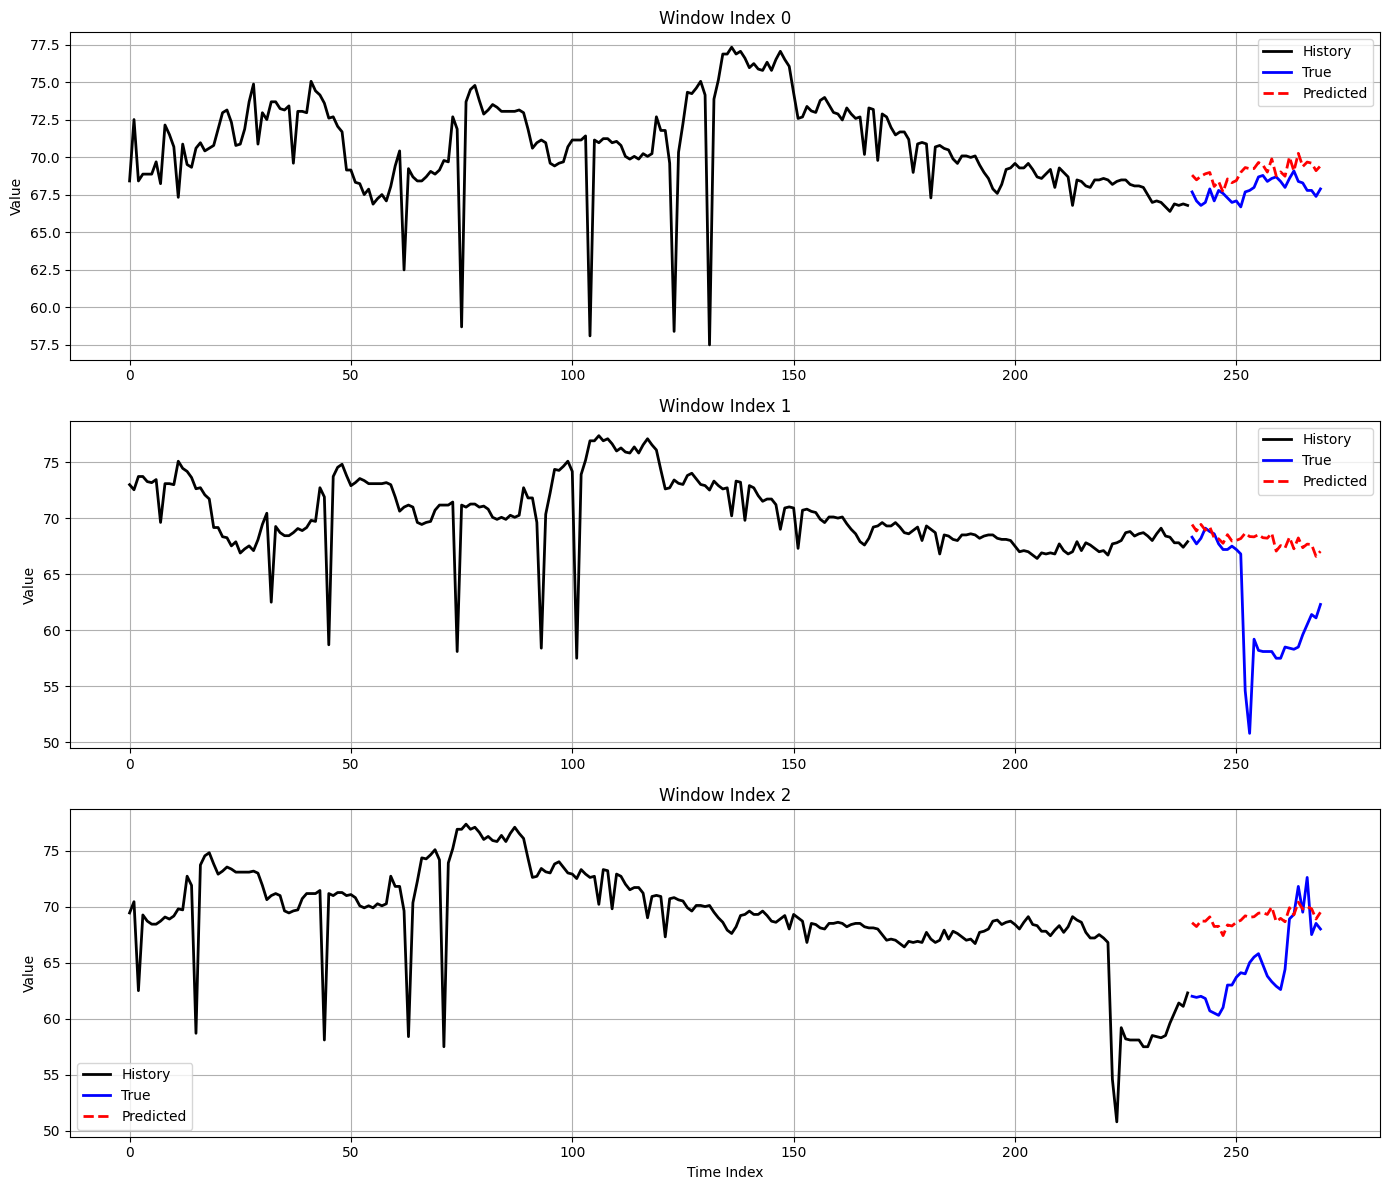

In [39]:
plot_model_result_vertical(
    model_predict_true_window_dto_list=model_output_dto.model_output_predict_true_dtos
)